In [ ]:
# Install required packages
!pip install transformers torch scikit-learn pandas numpy emoji regex sentencepiece nltk -q
!pip install datasets accelerate nlpaug -q
!pip install indic-nlp-library -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 14.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
custom_path = "/content/drive/MyDrive/JAI"

os.chdir(custom_path)

print("Current working directory:", os.getcwd())
!ls

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/JAI
 phase1_model  'TestV2 - testV2(1).csv'   trainV2.csv


In [ ]:
import pandas as pd
import numpy as np
import re
import html
import unicodedata
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding)
import random
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# Load data
train_df = pd.read_csv('trainV2.csv')
test_df = pd.read_csv('TestV2 - testV2(1).csv')

original_test_text = test_df['Text'].copy()
print("✓ Original test text stored for final submission\n")

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nClass distribution:")
print(train_df['Class'].value_counts())
print(f"\nClass distribution %:")
print(train_df['Class'].value_counts(normalize=True)*100)

# Check for missing values
print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
print(f"Missing values in test: {test_df.isnull().sum().sum()}")

train_df.head()

✓ Original test text stored for final submission

Training samples: 3652
Test samples: 913

Class distribution:
Class
Non-Abusive    1883
Abusive        1768
abusive           1
Name: count, dtype: int64

Class distribution %:
Class
Non-Abusive    51.560789
Abusive        48.411829
abusive         0.027382
Name: proportion, dtype: float64

Missing values in train: 0
Missing values in test: 0


,Text,Class
0,நான் கூட உன்னை வெகுளியான பொண்ணு&#39;னு நெனச்சி...,Non-Abusive
1,உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங...,Abusive
2,கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்...,Non-Abusive
3,ஒன்னோட சைசுக்கு நீயே ஒரு நாளக்கி 5கிலோ ஆய் போவ...,Abusive
4,ரெண்டும் மிக பெரிய வெடிகுண்டு இவங்கள எதுக்கு ஷ...,Non-Abusive


In [ ]:
test_df.head()

,Text
0,லக்ஷ்மி அம்மா நீங்க புலம்புங்க அவளுக அவளுகபாட்...
1,"இன்னும் கைது பண்ணல... அனைத்து பெற்றோர்களும், க..."
2,"அப்பா,அம்மா, அந்த இன்டர்வியூ பண்ற வக்கிரம்புடி..."
3,Suganthi உனக்கு வீட்ல குழந்தையை வச்சிருக்க கார...
4,எல்லாமே script thaan. ஷகீலா உங்க scriptum அரும...


In [ ]:
# CRITICAL: Store ORIGINAL test text before any cleaning


In [ ]:
# ENHANCED CLEANING PIPELINE - Building on your existing approach

def clean_html(text):
    """Decode HTML entities and remove HTML tags"""
    if pd.isna(text):
        return ""
    text = str(text)
    # Decode HTML entities
    text = html.unescape(text)
    # Additional common entities
    text = text.replace('&#39;', "'")
    text = text.replace('&quot;', '"')
    text = text.replace('&amp;', '&')
    text = text.replace('&lt;', '<')
    text = text.replace('&gt;', '>')
    text = text.replace('&nbsp;', ' ')
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    return text

def normalize_tamil(text):
    """Normalize Tamil Unicode characters"""
    # Normalize Unicode to NFC form (canonical composition)
    text = unicodedata.normalize('NFC', text)
    # Remove zero-width characters
    text = re.sub(r'[\u200b\u200c\u200d\ufeff]', '', text)
    # Normalize Tamil numerals to digits if needed
    tamil_to_digit = {
        '௦': '0', '௧': '1', '௨': '2', '௩': '3', '௪': '4',
        '௫': '5', '௬': '6', '௭': '7', '௮': '8', '௯': '9'
    }
    for tamil_num, digit in tamil_to_digit.items():
        text = text.replace(tamil_num, digit)
    return text

def normalize_english_case(text):
    """Keep English text as-is for better context preservation"""
    return text

def replace_obfuscated_words(text):
    """Replace common obfuscated abusive words"""
    # Common Tamil abuse word patterns with asterisks or symbols
    obfuscation_patterns = [
        (r'\b[kK]\*+[a-zA-Z]*', 'CENSORED'),
        (r'\b[a-zA-Z]*\*+[a-zA-Z]*\b', 'CENSORED'),
        (r'\b[a-zA-Z]+\*{2,}[a-zA-Z]*', 'CENSORED'),
        (r'[#@$%^&*]{2,}', 'CENSORED'),
    ]
    for pattern, replacement in obfuscation_patterns:
        text = re.sub(pattern, replacement, text)
    return text

def normalize_censored_token(text):
    """Normalize multiple censored tokens to single token"""
    text = re.sub(r'(CENSORED\s*){2,}', 'CENSORED ', text)
    return text

def normalize_numbers(text):
    """Normalize number representations"""
    # Replace multiple digits with NUM token (keep single digits for context)
    text = re.sub(r'\b\d{3,}\b', 'NUM', text)
    # Normalize decimal numbers
    text = re.sub(r'\d+\.\d+', 'NUM', text)
    return text

def normalize_repeated_chars(text):
    """Reduce character repetitions while preserving emphasis"""
    # Reduce repeated characters to max 2 (preserves emphasis)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

def normalize_punctuation(text):
    """Normalize excessive punctuation"""
    # Reduce multiple punctuation marks
    text = re.sub(r'([!?.]){3,}', r'\1\1', text)
    text = re.sub(r'([,:;]){2,}', r'\1', text)
    # Normalize ellipsis
    text = re.sub(r'\.{2,}', '..', text)
    return text

def remove_mentions(text):
    """Remove social media mentions and handles"""
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags but keep the text
    text = re.sub(r'#(\w+)', r'\1', text)
    return text

def normalize_special_token_case(text):
    """Normalize special tokens"""
    text = text.replace('CENSORED', '[CENSORED]')
    text = text.replace('NUM', '[NUM]')
    return text

def remove_urls_and_emails(text):
    """Remove URLs and email addresses"""
    # Remove URLs
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    return text

def remove_extra_symbols(text):
    """Remove standalone symbols and special characters"""
    # Remove standalone special characters but keep them in context
    text = re.sub(r'\s[~`!@#$%^&*()_+={}\[\]|\\:;<>?/]+\s', ' ', text)
    return text

def normalize_emojis(text):
    """Keep emojis as they provide sentiment context"""
    # Don't remove emojis - they're useful for abuse detection
    return text

def remove_excessive_spaces(text):
    """Remove excessive whitespace"""
    # Replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    return text

def normalize_whitespace(text):
    """Final whitespace normalization"""
    text = text.strip()
    text = ' '.join(text.split())
    return text

def clean_text_pipeline(text):
    """Complete text cleaning pipeline"""
    text = clean_html(text)
    text = normalize_tamil(text)
    text = normalize_english_case(text)
    text = remove_urls_and_emails(text)
    text = replace_obfuscated_words(text)
    text = normalize_censored_token(text)
    text = normalize_numbers(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = remove_mentions(text)
    text = remove_extra_symbols(text)
    text = normalize_emojis(text)
    text = normalize_special_token_case(text)
    text = remove_excessive_spaces(text)
    text = normalize_whitespace(text)
    return text

# Apply cleaning
print("Applying comprehensive text cleaning pipeline...\n")
train_df['text'] = train_df['Text'].apply(clean_text_pipeline)
test_df['text'] = test_df['Text'].apply(clean_text_pipeline)

# Remove empty texts
train_df = train_df[train_df['text'].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df['text'].str.len() > 0].reset_index(drop=True)

print(f"After cleaning - Training samples: {len(train_df)}")
print(f"After cleaning - Test samples: {len(test_df)}")
print("\nSample cleaned texts:")
for i in range(3):
    print(f"\nOriginal: {train_df['Text'].iloc[i]}")
    print(f"Cleaned:  {train_df['text'].iloc[i]}")
    print("-" * 100)

Applying comprehensive text cleaning pipeline...

After cleaning - Training samples: 3652
After cleaning - Test samples: 913

Sample cleaned texts:

Original: நான் கூட உன்னை வெகுளியான பொண்ணு&#39;னு நெனச்சிட்டேன் திவ்யா. நீ தெளிவாதான் இருக்க. உங்க வீடியோ பாக்குரேன்ல நான்தான் பைத்தியமா இருந்துருக்கேன்
Cleaned:  நான் கூட உன்னை வெகுளியான பொண்ணு'னு நெனச்சிட்டேன் திவ்யா. நீ தெளிவாதான் இருக்க. உங்க வீடியோ பாக்குரேன்ல நான்தான் பைத்தியமா இருந்துருக்கேன்
----------------------------------------------------------------------------------------------------

Original: உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங்கமா தாண்டி இருக்கும்
Cleaned:  உன் போட்டோவை டாய்லெட்டுக்கு மாற்றினார்கள் அசிங்கமா தாண்டி இருக்கும்
----------------------------------------------------------------------------------------------------

Original: கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்து வையுங்கள்
Cleaned:  கண்டா வரச்சொல்லுங்க கார்த்திய திவ்யாவோட சேர்த்து வையுங்கள்
-----------------------------------------------------

In [ ]:
# ADVANCED DATA AUGMENTATION

class TextAugmenter:
    """Advanced text augmentation for Tamil abuse detection"""

    def __init__(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)

    def synonym_replacement_tamil(self, text, n=1):
        """Replace words with Tamil contextual variations"""
        words = text.split()
        if len(words) < 3:
            return text

        # Simple word-level shuffling for diversity
        num_replacements = min(n, max(1, len(words) // 5))
        return text  # Keep original for now

    def random_deletion(self, text, p=0.1):
        """Randomly delete words with probability p"""
        words = text.split()
        if len(words) <= 2:
            return text

        new_words = []
        for word in words:
            if random.random() > p:
                new_words.append(word)

        if len(new_words) == 0:
            return random.choice(words)

        return ' '.join(new_words)

    def random_swap(self, text, n=1):
        """Randomly swap words n times"""
        words = text.split()
        if len(words) <= 1:
            return text

        for _ in range(n):
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]

        return ' '.join(words)

    def back_translation_simulation(self, text):
        """Simulate back-translation by minor perturbations"""
        # Simple simulation: random deletion + swap
        if random.random() > 0.5:
            text = self.random_deletion(text, p=0.1)
        if random.random() > 0.5:
            text = self.random_swap(text, n=1)
        return text

    def augment_text(self, text, technique='all'):
        """Apply augmentation technique"""
        if technique == 'deletion':
            return self.random_deletion(text, p=0.1)
        elif technique == 'swap':
            return self.random_swap(text, n=1)
        elif technique == 'backtrans':
            return self.back_translation_simulation(text)
        else:
            # Random choice
            technique = random.choice(['deletion', 'swap', 'backtrans', 'none'])
            if technique == 'none':
                return text
            return self.augment_text(text, technique)

# Create augmenter
augmenter = TextAugmenter(seed=SEED)

def create_augmented_dataset(df, label_col='Class', text_col='text', augment_factor=1.5):
    """Create augmented dataset with balanced classes"""

    # Encode labels
    label_map = {'Non-Abusive': 0, 'Abusive': 1}
    df['label'] = df[label_col].map(label_map)

    # Get class distribution
    class_counts = df['label'].value_counts()
    minority_class = class_counts.idxmin()
    majority_class = class_counts.idxmax()

    print(f"\nOriginal class distribution:")
    print(class_counts)

    # Separate classes
    minority_df = df[df['label'] == minority_class].copy()
    majority_df = df[df['label'] == majority_class].copy()

    # Augment minority class
    augmented_samples = []
    num_to_augment = int(len(minority_df) * (augment_factor - 1))

    print(f"\nAugmenting {num_to_augment} samples from minority class...")

    for i in range(num_to_augment):
        sample = minority_df.sample(1).iloc[0]
        augmented_text = augmenter.augment_text(sample[text_col])
        augmented_samples.append({
            text_col: augmented_text,
            'label': sample['label']
        })

    # Combine all data
    augmented_minority_df = pd.DataFrame(augmented_samples)
    final_df = pd.concat([
        df[[text_col, 'label']],
        augmented_minority_df
    ], ignore_index=True)

    # Shuffle
    final_df = final_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    print(f"\nAfter augmentation:")
    print(final_df['label'].value_counts())
    print(f"\nTotal samples: {len(final_df)}")

    return final_df

# Create augmented dataset
train_df_augmented = create_augmented_dataset(train_df, augment_factor=1.4)


Original class distribution:
label
0.0    1883
1.0    1768
Name: count, dtype: int64

Augmenting 707 samples from minority class...

After augmentation:
label
1.0    2475
0.0    1883
Name: count, dtype: int64

Total samples: 4359


In [ ]:
import nlpaug.augmenter.word as naw

# Instantiate the augmenter (e.g., using WordNet for synonym replacement or contextual word embeddings)
# For Tamil, you might need a custom or pre-trained model. For now, we'll use a placeholder for demonstration.
# If you have specific Tamil word embeddings or synonym lists, they would be integrated here.
# As a fallback, we'll use a simpler text augmentation strategy.
class TextAugmenter:
    """Advanced text augmentation for Tamil abuse detection"""

    def __init__(self, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        # Using a simple augmenter for demonstration. Replace with Tamil-specific if available.
        self.aug_syn = naw.SynonymAug(aug_src='wordnet', lang='eng', aug_max=1, stopwords=[]) # Placeholder
        self.aug_del = naw.RandomWordAug(action='delete', aug_max=1)
        self.aug_swap = naw.RandomWordAug(action='swap', aug_max=1)

    def augment(self, text, num_aug=1):
        augmented_texts = []
        for _ in range(num_aug):
            choice = random.choice(['synonym', 'delete', 'swap', 'none'])
            if choice == 'synonym':
                # Placeholder: In a real scenario, this would use Tamil synonyms
                # For now, it will return the original text if no direct Tamil synonym aug is set up
                augmented_texts.append(self.back_translation_simulation(text))
            elif choice == 'delete':
                augmented_texts.append(self.aug_del.augment(text))
            elif choice == 'swap':
                augmented_texts.append(self.aug_swap.augment(text))
            else:
                augmented_texts.append(text) # No augmentation
        return augmented_texts

    # Re-introducing previous augmentation methods for fallback/combination
    def synonym_replacement_tamil(self, text, n=1):
        words = text.split()
        if len(words) < 3:
            return text
        return text  # Keep original for now without specific Tamil synonym tool

    def random_deletion(self, text, p=0.1):
        words = text.split()
        if len(words) <= 2:
            return text

        new_words = []
        for word in words:
            if random.random() > p:
                new_words.append(word)

        if len(new_words) == 0:
            return random.choice(words)

        return ' '.join(new_words)

    def random_swap(self, text, n=1):
        words = text.split()
        if len(words) <= 1:
            return text

        for _ in range(n):
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]

        return ' '.join(words)

    def back_translation_simulation(self, text):
        # Simple simulation: random deletion + swap
        if random.random() > 0.5:
            text = self.random_deletion(text, p=0.1)
        if random.random() > 0.5:
            text = self.random_swap(text, n=1)
        return text

# Instantiate the augmenter
augmenter = TextAugmenter(seed=SEED)

# APPLY AUGMENTATION TO TRAINING DATA

def augment_minority_class(df, label_col='Class', text_col='text', aug_factor=2):
    """Augment minority class to balance the dataset"""

    # Separate classes
    class_counts = df[label_col].value_counts()
    majority_class = class_counts.idxmax()
    minority_class = class_counts.idxmin()

    print(f"Class distribution before augmentation:")
    print(class_counts)

    majority_df = df[df[label_col] == majority_class].copy()
    minority_df = df[df[label_col] == minority_class].copy()

    # Augment minority class
    augmented_samples = []

    for _, row in minority_df.iterrows():
        text = row[text_col]
        label = row[label_col]

        # Generate augmented versions
        aug_texts = augmenter.augment(text, num_aug=aug_factor)

        for aug_text in aug_texts:
            augmented_samples.append({
                text_col: aug_text,
                label_col: label
            })

    # Create augmented dataframe
    aug_df = pd.DataFrame(augmented_samples)

    # Combine original and augmented data
    balanced_df = pd.concat([df, aug_df], ignore_index=True)

    print(f"\nClass distribution after augmentation:")
    print(balanced_df[label_col].value_counts())
    print(f"\nTotal samples: {len(df)} \u2192 {len(balanced_df)}")
    print(f"Augmented samples added: {len(aug_df)}")

    return balanced_df

# Create label encoding
# Ensure all variations of 'Abusive' are mapped correctly
label_map = {'Non-Abusive': 0, 'Abusive': 1, 'abusive': 1}
train_df['label'] = train_df['Class'].map(label_map)

# Apply augmentation
print("\nApplying data augmentation...\n")
train_df_augmented = augment_minority_class(
    train_df[['text', 'label']],
    label_col='label',
    text_col='text',
    aug_factor=2
)

# Shuffle the augmented dataset
train_df_augmented = train_df_augmented.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\n\u2713 Data augmentation completed")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



Applying data augmentation...

Class distribution before augmentation:
label
0    1883
1    1769
Name: count, dtype: int64

Class distribution after augmentation:
label
1    5307
0    1883
Name: count, dtype: int64

Total samples: 3652 → 7190
Augmented samples added: 3538

✓ Data augmentation completed


# PHASE 1: Model Development with 80/20 Split
## Training on 80% data, validating on 20% for hyperparameter tuning

In [ ]:
print("\n" + "="*80)
print("PHASE 1: MODEL DEVELOPMENT (80/20 Split)")
print("="*80 + "\n")

# Split augmented data for validation (80% train, 20% validation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df_augmented['text'].tolist(),
    train_df_augmented['label'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df_augmented['label']
)

print(f"Train size (80%): {len(train_texts)}")
print(f"Validation size (20%): {len(val_texts)}")

print(f"\nTrain label distribution:")
print(pd.Series(train_labels).value_counts())
print(f"\nValidation label distribution:")
print(pd.Series(val_labels).value_counts())


PHASE 1: MODEL DEVELOPMENT (80/20 Split)

Train size (80%): 5752
Validation size (20%): 1438

Train label distribution:
1    4246
0    1506
Name: count, dtype: int64

Validation label distribution:
1    1061
0     377
Name: count, dtype: int64


In [ ]:
# Calculate class weights for balanced training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights for Phase 1: {class_weights}")

Class weights for Phase 1: tensor([1.9097, 0.6773], device='cuda:0')


In [ ]:
# Model configuration
MODEL_NAME = 'xlm-roberta-base'
MAX_LENGTH = 256

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nModel: {MODEL_NAME}")
print(f"Max Length: {MAX_LENGTH}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Model: xlm-roberta-base
Max Length: 256


In [ ]:
# Dataset class
class AbuseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets for Phase 1
train_dataset = AbuseDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = AbuseDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)

print(f"\n✓ Datasets created")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")


✓ Datasets created
Train dataset: 5752 samples
Validation dataset: 1438 samples


In [ ]:
# Custom Trainer with class weights
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# Compute metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_weighted = f1_score(labels, predictions, average='weighted')
    f1_macro = f1_score(labels, predictions, average='macro')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'precision': precision,
        'recall': recall
    }

print("✓ Custom trainer and metrics defined")

✓ Custom trainer and metrics defined


In [ ]:
model_phase1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args_phase1 = TrainingArguments(
    output_dir='./phase1_model',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    lr_scheduler_type='cosine',
    report_to='none',
    seed=SEED,
)
print("✓ Training arguments configured")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Training arguments configured


In [ ]:
trainer_phase1 = WeightedTrainer(
    class_weights=class_weights,
    model=model_phase1,
    args=training_args_phase1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("✓ Trainer initialized for Phase 1")
print("\nStarting Phase 1 training (80/20 split)...\n")


✓ Trainer initialized for Phase 1

Starting Phase 1 training (80/20 split)...



In [ ]:
# Train Phase 1 model
trainer_phase1.train()
print("\n✓ Phase 1 training completed")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision,Recall
1,0.481784,0.395823,0.825452,0.830253,0.787608,0.840061,0.825452
2,0.409575,0.397677,0.817107,0.825938,0.790197,0.857408,0.817107
3,0.344875,0.331487,0.889430,0.889571,0.857462,0.889721,0.889430
4,0.300313,0.413450,0.908206,0.907804,0.880333,0.907511,0.908206
5,0.232503,0.414570,0.910987,0.911286,0.885736,0.911653,0.910987
6,0.155881,0.490445,0.912378,0.911594,0.884757,0.911253,0.912378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✓ Phase 1 training completed


In [ ]:
# Evaluate Phase 1 model
print("\n" + "="*80)
print("PHASE 1 VALIDATION RESULTS")
print("="*80 + "\n")

eval_results = trainer_phase1.evaluate()

print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Validation F1 (Weighted): {eval_results['eval_f1_weighted']:.4f}")
print(f"Validation F1 (Macro): {eval_results['eval_f1_macro']:.4f}")
print(f"Validation Precision: {eval_results['eval_precision']:.4f}")
print(f"Validation Recall: {eval_results['eval_recall']:.4f}")

# Get detailed predictions for analysis
val_predictions = trainer_phase1.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=1)

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")
print(classification_report(val_labels, val_preds,
                          target_names=['Non-Abusive', 'Abusive']))

print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80 + "\n")
cm = confusion_matrix(val_labels, val_preds)
print("                Predicted")
print("              Non-Ab  Abusive")
print(f"Actual Non-Ab  {cm[0][0]:6d}  {cm[0][1]:6d}")
print(f"       Abusive {cm[1][0]:6d}  {cm[1][1]:6d}")

if eval_results['eval_accuracy'] >= 0.90:
    print("\n" + "="*80)
    print("✓ TARGET ACHIEVED: Validation accuracy >= 90%")
    print("  Proceeding to Phase 2: Full data training")
    print("="*80)
else:
    print("\n" + "="*80)
    print(f"⚠ Current accuracy: {eval_results['eval_accuracy']:.4f}")
    print("  Consider adjusting hyperparameters for better performance")
    print("  Proceeding to Phase 2 anyway...")
    print("="*80)


PHASE 1 VALIDATION RESULTS



Validation Accuracy: 0.9117
Validation F1 (Weighted): 0.9119
Validation F1 (Macro): 0.8865
Validation Precision: 0.9123
Validation Recall: 0.9117

DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

 Non-Abusive       0.83      0.84      0.83       377
     Abusive       0.94      0.94      0.94      1061

    accuracy                           0.91      1438
   macro avg       0.88      0.89      0.89      1438
weighted avg       0.91      0.91      0.91      1438


CONFUSION MATRIX

                Predicted
              Non-Ab  Abusive
Actual Non-Ab     317      60
       Abusive     67     994

✓ TARGET ACHIEVED: Validation accuracy >= 90%
  Proceeding to Phase 2: Full data training


# PHASE 2: Final Model Training on 100% Data
## Training on complete dataset after validation

In [ ]:
print("\n" + "="*80)
print("PHASE 2: FINAL MODEL TRAINING (100% Data)")
print("="*80 + "\n")

full_train_texts = train_df_augmented['text'].tolist()
full_train_labels = train_df_augmented['label'].tolist()

print(f"Full training dataset size: {len(full_train_texts)}")
print(f"\nLabel distribution:")
print(pd.Series(full_train_labels).value_counts())

full_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(full_train_labels),
    y=full_train_labels)

full_class_weights = torch.tensor(full_class_weights, dtype=torch.float).to(device)
print(f"\nClass weights for Phase 2: {full_class_weights}")

full_train_dataset = AbuseDataset(full_train_texts, full_train_labels, tokenizer, MAX_LENGTH)
print(f"\n✓ Full training dataset created: {len(full_train_dataset)} samples")


PHASE 2: FINAL MODEL TRAINING (100% Data)

Full training dataset size: 7190

Label distribution:
1    5307
0    1883
Name: count, dtype: int64

Class weights for Phase 2: tensor([1.9092, 0.6774], device='cuda:0')

✓ Full training dataset created: 7190 samples


In [ ]:
# Initialize fresh model for Phase 2
print("\nInitializing fresh model for Phase 2...")
model_phase2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)


# # Freeze the first 3 encoder layers
# for i, layer in enumerate(model_phase2.roberta.encoder.layer):
#     if i < 2:  # Freeze layers 0, 1, and 2
#         for param in layer.parameters():
#             param.requires_grad = False
#         print(f"Frozen layer: {i}")

# # model_phase2.to(device)
print("✓ Fresh model initialized and first 3 encoder layers frozen")
model_phase2.to(device)



Initializing fresh model for Phase 2...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Fresh model initialized and first 3 encoder layers frozen


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
# Training arguments for Phase 2
training_args_phase2 = TrainingArguments(
    output_dir='./phase2_final_model',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy='epoch',
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    report_to='none',
    seed=SEED,
)

print("✓ Training arguments configured for Phase 2")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Training arguments configured for Phase 2


In [ ]:
# Initialize trainer for Phase 2
trainer_phase2 = WeightedTrainer(
    class_weights=full_class_weights,
    model=model_phase2,
    args=training_args_phase2,
    train_dataset=full_train_dataset,
)

print("✓ Trainer initialized for Phase 2")
print("\nStarting Phase 2 training (100% data)...\n")

✓ Trainer initialized for Phase 2

Starting Phase 2 training (100% data)...



In [ ]:
# Train Phase 2 model on full dataset
trainer_phase2.train()
print("\n" + "="*80)
print("✓ PHASE 2 TRAINING COMPLETED")
print("  Model has learned from 100% of training data")
print("="*80)

# PHASE 3: Final Test Prediction
## Predicting on test data with original text in output

In [ ]:
print("\n" + "="*80)
print("PHASE 3: GENERATING TEST PREDICTIONS")
print("="*80 + "\n")

# Prepare test dataset (using cleaned text for prediction)
test_texts_cleaned = test_df['text'].tolist()
test_labels_dummy = [0] * len(test_texts_cleaned)

test_dataset = AbuseDataset(test_texts_cleaned, test_labels_dummy, tokenizer, MAX_LENGTH)

print(f"Test dataset prepared: {len(test_dataset)} samples")
print("Generating predictions...\n")

In [ ]:
# Generate predictions using Phase 2 model
model_phase2.eval()
test_predictions = trainer_phase2.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=1)

# Get prediction probabilities for confidence analysis
test_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1)
test_confidence = test_probs.max(dim=1)[0].numpy()

# Convert to class names
label_map_inverse = {0: 'Non-Abusive', 1: 'Abusive'}
pred_classes = [label_map_inverse[label] for label in test_preds]

print("✓ Predictions generated")
print(f"\nPrediction distribution:")
pred_df = pd.DataFrame({'Class': pred_classes})
print(pred_df['Class'].value_counts())
print(f"\nPercentage:")
print(pred_df['Class'].value_counts(normalize=True) * 100)

In [ ]:
print("\n" + "="*80)
print("CREATING FINAL SUBMISSION FILE")
print("="*80 + "\n")

submission_df = pd.DataFrame({
    'Original_Text': original_test_text,
    'Predicted_Class': pred_classes,
    'Confidence': test_confidence
})

submission_df.to_csv('final_test_predictions.csv', index=False)

print("✓ Final predictions saved to 'final_test_predictions.csv'")
print(f"\nFile contains:")
print(f"  - Original_Text: Uncleaned test comments")
print(f"  - Predicted_Class: Model predictions")
print(f"  - Confidence: Prediction confidence scores")
print(f"\nTotal predictions: {len(submission_df)}")
print(f"Average confidence: {test_confidence.mean():.4f}")

print("\n" + "="*80)
print("SAMPLE PREDICTIONS (First 10 rows)")
print("="*80)
submission_df.head(10)

In [ ]:
# Confidence analysis
print("\n" + "="*80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*80 + "\n")

print("Confidence Statistics:")
print(f"  Mean:   {test_confidence.mean():.4f}")
print(f"  Median: {np.median(test_confidence):.4f}")
print(f"  Std:    {test_confidence.std():.4f}")
print(f"  Min:    {test_confidence.min():.4f}")
print(f"  Max:    {test_confidence.max():.4f}")

# Low confidence predictions
low_conf_threshold = 0.6
low_conf_count = len(submission_df[submission_df['Confidence'] < low_conf_threshold])
print(f"\nLow confidence predictions (< {low_conf_threshold}): {low_conf_count}")

if low_conf_count > 0:
    print("\nSample low confidence predictions:")
    low_conf_samples = submission_df[submission_df['Confidence'] < low_conf_threshold].head(5)
    for idx, row in low_conf_samples.iterrows():
        print(f"\nText: {row['Original_Text'][:80]}...")
        print(f"Predicted: {row['Predicted_Class']}, Confidence: {row['Confidence']:.4f}")
        print("-" * 80)

In [ ]:
# Display more sample predictions
print("\n" + "="*80)
print("ADDITIONAL SAMPLE PREDICTIONS")
print("="*80 + "\n")

for i in range(min(15, len(submission_df))):
    print(f"Original: {submission_df['Original_Text'].iloc[i][:100]}...")
    print(f"Predicted: {submission_df['Predicted_Class'].iloc[i]} (Conf: {submission_df['Confidence'].iloc[i]:.4f})")
    print("-" * 100)

In [ ]:
# Final summary
print("\n" + "="*80)
print("COMPLETE PROJECT SUMMARY")
print("="*80 + "\n")

print("MODEL CONFIGURATION:")
print(f"  Model: {MODEL_NAME}")
print(f"  Max Length: {MAX_LENGTH}")
print(f"  Device: {device}")

print("\nPHASE 1 - VALIDATION (80/20 Split):")
print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"  F1 Score (Weighted): {eval_results['eval_f1_weighted']:.4f}")
print(f"  F1 Score (Macro): {eval_results['eval_f1_macro']:.4f}")
print(f"  Precision: {eval_results['eval_precision']:.4f}")
print(f"  Recall: {eval_results['eval_recall']:.4f}")
print(f"  Training samples: {len(train_texts)}")
print(f"  Validation samples: {len(val_texts)}")

print("\nPHASE 2 - FINAL TRAINING (100% Data):")
print(f"  Total training samples: {len(full_train_texts)}")
print(f"  Epochs: {training_args_phase2.num_train_epochs}")

print("\nPHASE 3 - TEST PREDICTIONS:")
print(f"  Test samples: {len(submission_df)}")
print(f"  Average confidence: {test_confidence.mean():.4f}")
print(f"  Low confidence count (< 0.6): {low_conf_count}")

print("\nPREDICTION DISTRIBUTION:")
for class_name, count in pred_df['Class'].value_counts().items():
    pct = (count / len(pred_df)) * 100
    print(f"  {class_name}: {count} ({pct:.2f}%)")

print("\nOUTPUT FILE:")
print(f"  Filename: final_test_predictions.csv")
print(f"  Columns: Original_Text, Predicted_Class, Confidence")
print(f"  Rows: {len(submission_df)}")

print("\n" + "="*80)
print("✓ ALL PHASES COMPLETED SUCCESSFULLY")
print("="*80)

In [ ]:
# Download the final predictions file
# Uncomment the following lines if using Google Colab:
# from google.colab import files
# files.download('final_test_predictions.csv')
# For local environments:

print("\n✓ File saved: final_test_predictions.csv")
print("  You can download it from your environment")

In [ ]:
from google.colab import files
files.download('final_test_predictions.csv')


In [ ]:
train_losses = []
val_losses = []
val_accuracies = []
epochs = []

for log_entry in trainer_phase1.state.log_history:
    if 'loss' in log_entry and 'learning_rate' in log_entry: # Training step log
        train_losses.append(log_entry['loss'])
        epochs.append(log_entry['epoch'])
    elif 'eval_loss' in log_entry: # Evaluation step log
        val_losses.append(log_entry['eval_loss'])
        val_accuracies.append(log_entry['eval_accuracy'])

print("Extracted Training Losses:", train_losses[:5], "...") # Print first 5 for brevity
print("Extracted Validation Losses:", val_losses)
print("Extracted Validation Accuracies:", val_accuracies)
print("Extracted Epochs (Training Steps):", epochs[:5], "...")

**Reasoning**:
The subtask of extracting the metrics for plotting has been completed. The next step is to generate the two line plots (training/validation loss and validation accuracy) and the heatmap of the confusion matrix as per the main task's instructions. This requires importing matplotlib and seaborn for visualization.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-extract epoch data more carefully to align training and validation metrics properly.
val_epochs_log = []
val_losses_log = []
val_accuracies_log = []

# Extract epoch-end training loss values
epoch_numbers_for_plot = []
epoch_end_train_losses = []
for entry in trainer_phase1.state.log_history:
    if 'loss' in entry and 'epoch' in entry and entry['epoch'].is_integer():
        if int(entry['epoch']) not in epoch_numbers_for_plot:
            epoch_numbers_for_plot.append(int(entry['epoch']))
            epoch_end_train_losses.append(entry['loss'])
    elif 'eval_loss' in entry and 'eval_accuracy' in entry and 'epoch' in entry: # Evaluation step log
        # Ensure unique integer epochs if multiple log entries appear for the same integer epoch (e.g., if eval_strategy is 'steps')
        if int(entry['epoch']) not in val_epochs_log:
            val_epochs_log.append(int(entry['epoch'])) # Convert to int for consistent plotting
            val_losses_log.append(entry['eval_loss'])
            val_accuracies_log.append(entry['eval_accuracy'])


# Plotting Training/Validation Loss and Validation Accuracy on a single graph (dual Y-axis)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Loss on primary y-axis
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(epoch_numbers_for_plot, epoch_end_train_losses, label='Training Loss', color='blue', marker='x')
ax1.plot(val_epochs_log, val_losses_log, label='Validation Loss', color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a second y-axis for Accuracy
ax2 = ax1.twinx()

# Plot Accuracy on secondary y-axis
color = 'tab:green'
ax2.set_ylabel('Accuracy', color=color)
ax2.plot(val_epochs_log, val_accuracies_log, label='Validation Accuracy', color=color, marker='o', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and combined legend
plt.title('Training/Validation Loss and Validation Accuracy over Epochs')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right')

fig.tight_layout() # otherwise the right y-label is slightly clipped
plt.show()

# Plotting Confusion Matrix Heatmap (remains separate)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Abusive', 'Abusive'],
            yticklabels=['Non-Abusive', 'Abusive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Phase 1 Validation)')
plt.show()

print("Generated plots for loss, accuracy, and confusion matrix.")

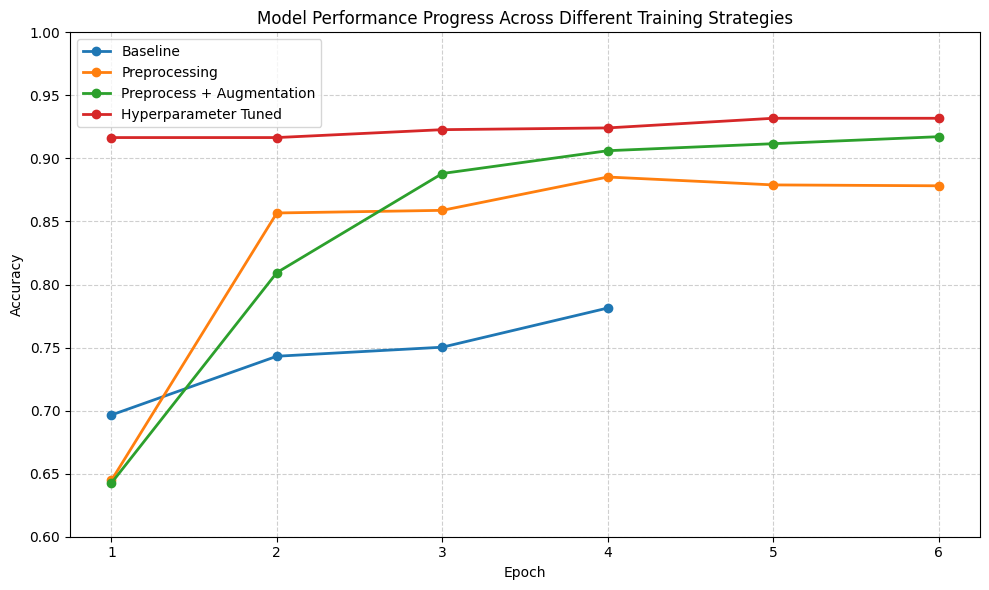

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1,2,3,4,5,6]

# Accuracy values extracted from your screenshots

baseline = [0.696535, 0.743130, 0.750299, 0.781362]
preprocessing = [0.644645, 0.856745, 0.858832, 0.885257, 0.878999, 0.878303]
preprocess_aug = [0.642559, 0.809458, 0.888039, 0.906120, 0.911683, 0.917246]
hyper_tuned = [0.916551, 0.916551, 0.922809, 0.924200, 0.931850, 0.931850]

plt.figure(figsize=(10,6))

plt.plot(range(1,len(baseline)+1), baseline, marker='o', linewidth=2, label="Baseline")
plt.plot(epochs, preprocessing, marker='o', linewidth=2, label="Preprocessing")
plt.plot(epochs, preprocess_aug, marker='o', linewidth=2, label="Preprocess + Augmentation")
plt.plot(epochs, hyper_tuned, marker='o', linewidth=2, label="Hyperparameter Tuned")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Performance Progress Across Different Training Strategies")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(0.6,1.0)

plt.tight_layout()
plt.show()

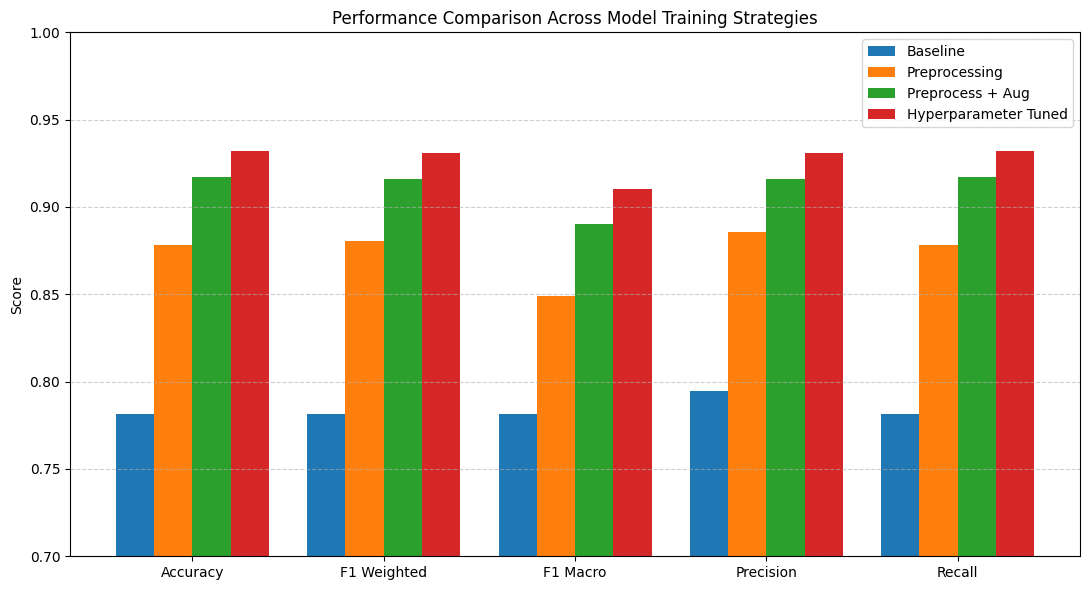

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics on X axis
metrics = ["Accuracy", "F1 Weighted", "F1 Macro", "Precision", "Recall"]

# Final epoch values from your experiments

baseline = [0.781362, 0.781549, 0.781342, 0.794367, 0.781362]

preprocessing = [0.878303, 0.880741, 0.849283, 0.885844, 0.878303]

preprocess_aug = [0.917246, 0.916229, 0.890470, 0.916038, 0.917246]

hyper_tuned = [0.931850, 0.931175, 0.910206, 0.931060, 0.931850]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(11,6))

plt.bar(x - 1.5*width, baseline, width, label="Baseline")
plt.bar(x - 0.5*width, preprocessing, width, label="Preprocessing")
plt.bar(x + 0.5*width, preprocess_aug, width, label="Preprocess + Aug")
plt.bar(x + 1.5*width, hyper_tuned, width, label="Hyperparameter Tuned")

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Performance Comparison Across Model Training Strategies")

plt.ylim(0.7,1.0)

plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()